In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import pi
from sklearn.preprocessing import MinMaxScaler

In [9]:
# ------------------------------------------------------------
# 1. Загрузка и агрегация данных для одного класса
# ------------------------------------------------------------

def aggregate_class(class_name, eval_path_pattern, maape_path_pattern):
    # 1.1 Загрузка поточечных метрик (smape, mase, rmsse)
    eval_file = eval_path_pattern.format(class_name)
    df_raw = pd.read_csv(eval_file)

    df_metrics = df_raw[df_raw['metric'].isin(['smape', 'mase', 'rmsse'])].copy()
    df_long = df_metrics.melt(id_vars=['unique_id', 'metric'],
                              var_name='model', value_name='value')
    df_long.dropna(subset=['value'], inplace=True)

    # ---- Фильтр: оставляем только DeepAR, исключаем все квантильные и median ----
    df_long = df_long[~df_long['model'].str.contains('DeepAR-lo|DeepAR-hi|DeepAR-median')]

    agg = df_long.groupby(['model', 'metric'])['value'].agg(['mean', 'median']).reset_index()
    agg.columns = ['model', 'metric', 'mean', 'median']

    pivot_mean = agg.pivot(index='model', columns='metric', values='mean')
    pivot_median = agg.pivot(index='model', columns='metric', values='median')

    pivot_mean.columns = [f'mean_{col}' for col in pivot_mean.columns]
    pivot_median.columns = [f'median_{col}' for col in pivot_median.columns]

    df_class = pivot_mean.join(pivot_median, how='outer')

    # 1.2 Загрузка агрегированных MAAPE
    maape_file = maape_path_pattern.format(class_name)
    df_maape = pd.read_csv(maape_file)
    df_maape.rename(columns={'Model': 'model'}, inplace=True)
    df_maape.set_index('model', inplace=True)

    # ---- В MAAPE тоже оставляем только DeepAR (если там есть лишние строки) ----
    df_maape = df_maape[~df_maape.index.str.contains('DeepAR-lo|DeepAR-hi|DeepAR-median')]

    df_class = df_class.join(df_maape[['MAAPE_mean', 'MAAPE_median']], how='inner')
    df_class.rename(columns={'MAAPE_mean': 'mean_maape', 'MAAPE_median': 'median_maape'}, inplace=True)

    required_cols = ['mean_smape', 'median_smape', 'mean_maape', 'median_maape',
                     'mean_mase', 'median_mase', 'mean_rmsse', 'median_rmsse']
    for col in required_cols:
        if col not in df_class.columns:
            df_class[col] = np.nan

    df_class.dropna(subset=['mean_smape', 'median_smape', 'mean_maape', 'median_maape'], inplace=True)
    return df_class[required_cols]

In [10]:
# ------------------------------------------------------------
# 2. Загрузка данных для всех классов
# ------------------------------------------------------------
classes = ['all', 'Smooth', 'Erratic', 'Intermittent', 'Lumpy']
class_data = {}

for cls in classes:
    print(f'Загрузка класса {cls}...')
    df_cls = aggregate_class(cls, 'evaluation_{}.csv', 'maape_aggregated_{}.csv')
    class_data[cls] = df_cls
    print(f'  Моделей: {len(df_cls)}')

Загрузка класса all...
  Моделей: 25
Загрузка класса Smooth...
  Моделей: 25
Загрузка класса Erratic...
  Моделей: 25
Загрузка класса Intermittent...
  Моделей: 25
Загрузка класса Lumpy...
  Моделей: 25


In [11]:
# ------------------------------------------------------------
# 3. Сохранение агрегированных таблиц
# ------------------------------------------------------------
output_excel = 'aggregated_metrics_all_classes.xlsx'
with pd.ExcelWriter(output_excel, engine='openpyxl') as writer:
    # Лист с данными по каждому классу
    for cls in classes:
        df = class_data[cls].copy()
        df.index.name = 'model'
        df.to_excel(writer, sheet_name=cls)

    # Функция для построения таблицы для тепловых карт (строки=классы, столбцы=модели)
    def build_heatmap_table(metric, agg_type='mean'):
        col_name = f'{agg_type}_{metric}'
        data = {}
        for cls in classes:
            df = class_data[cls]
            data[cls] = df[col_name]
        df_hm = pd.DataFrame(data).T
        df_hm = df_hm.reindex(sorted(df_hm.columns), axis=1)
        return df_hm

    # Сохраняем сводные таблицы для тепловых карт
    metrics_agg = [
        ('smape', 'mean'), ('smape', 'median'),
        ('maape', 'mean'), ('maape', 'median'),
        ('mase', 'median'), ('rmsse', 'median')
    ]
    for metric, agg in metrics_agg:
        df_hm = build_heatmap_table(metric, agg)
        df_hm_T = df_hm.T  # модели – строки, классы – столбцы
        sheet_name = f'{agg}_{metric}_by_class'
        df_hm_T.to_excel(writer, sheet_name=sheet_name)

    # Общая сводка: MultiIndex (класс, метрика) в колонках
    all_models = set()
    for df in class_data.values():
        all_models.update(df.index)
    all_models = sorted(all_models)
    columns = pd.MultiIndex.from_product([classes,
        ['mean_smape','median_smape','mean_maape','median_maape','median_mase','median_rmsse']])
    summary = pd.DataFrame(index=all_models, columns=columns)
    for cls in classes:
        df = class_data[cls]
        for model in all_models:
            if model in df.index:
                for metric in ['mean_smape','median_smape','mean_maape','median_maape','median_mase','median_rmsse']:
                    summary.loc[model, (cls, metric)] = df.loc[model, metric]
    summary.to_excel(writer, sheet_name='summary_all_classes')

print(f"Агрегированные таблицы сохранены в {output_excel}")

# Дополнительно CSV для каждого класса
for cls in classes:
    df = class_data[cls].copy()
    df.index.name = 'model'
    df.to_csv(f'aggregated_{cls}.csv')
print("CSV файлы для каждого класса также сохранены.")

Агрегированные таблицы сохранены в aggregated_metrics_all_classes.xlsx
CSV файлы для каждого класса также сохранены.


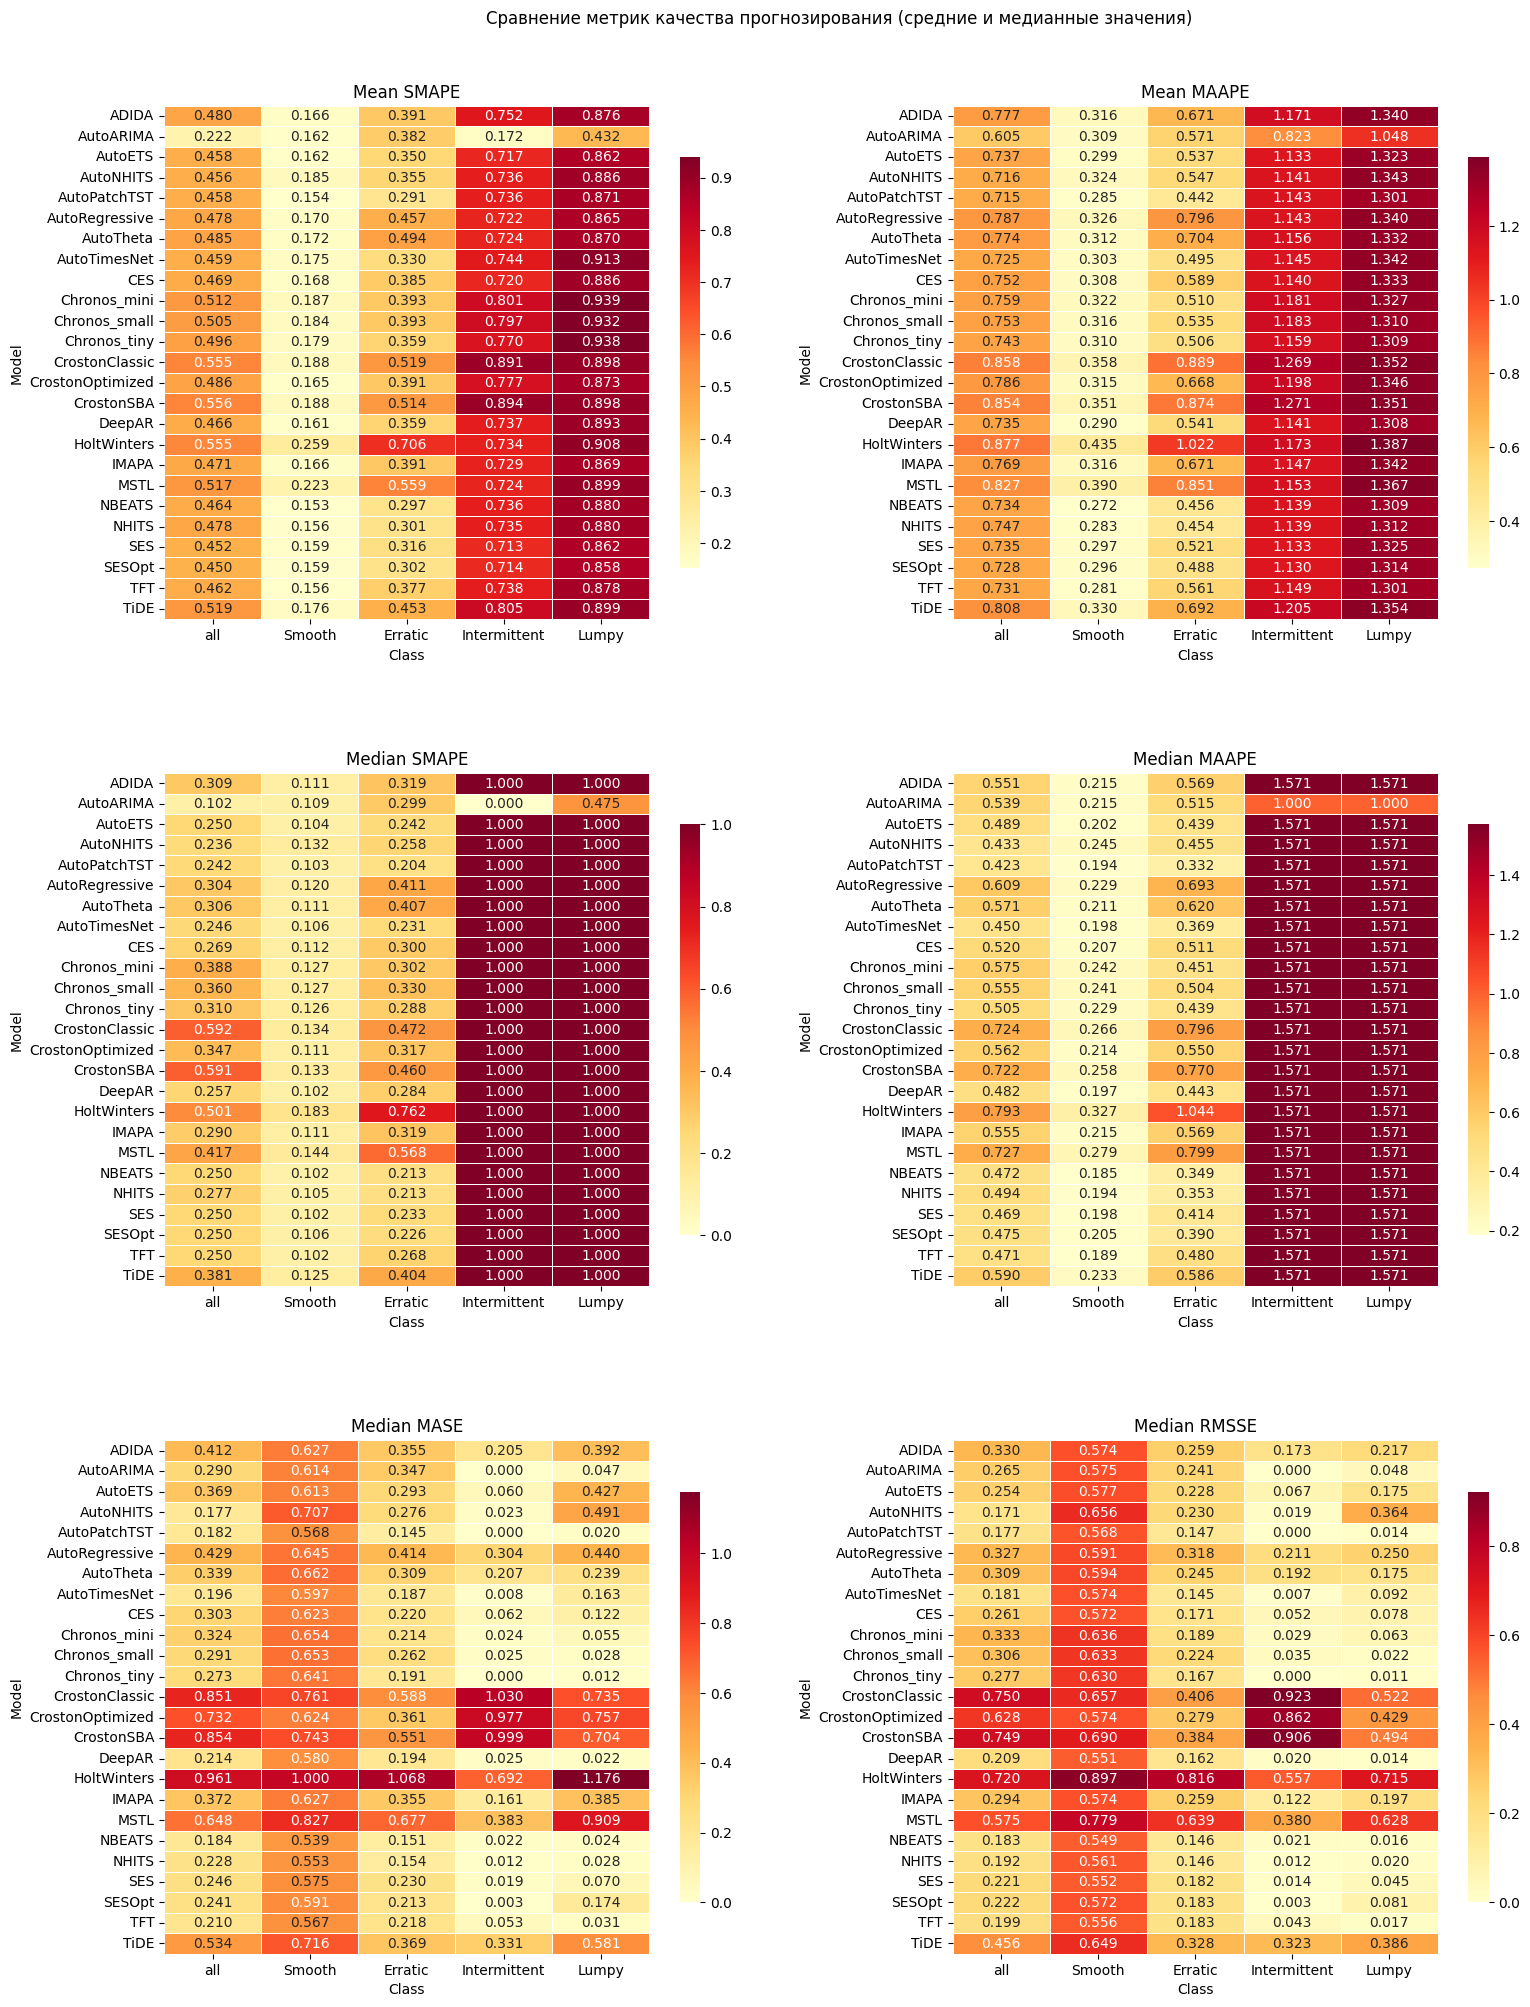

In [16]:
# ------------------------------------------------------------
# 4. Тепловые карты (все модели)
# ------------------------------------------------------------
def build_heatmap_table(metric, agg_type='mean'):
    """
    Возвращает DataFrame: строки = модели, столбцы = классы.
    """
    col_name = f'{agg_type}_{metric}'
    data = {}
    for cls in classes:
        df = class_data[cls]
        data[cls] = df[col_name]
    df_hm = pd.DataFrame(data)          # модели (индекс) x классы
    df_hm = df_hm.reindex(sorted(df_hm.index))  # сортировка моделей по алфавиту
    df_hm = df_hm[classes]               # фиксируем порядок классов
    return df_hm

fig, axes = plt.subplots(3, 2, figsize=(18, 24))
fig.subplots_adjust(hspace=0.3, wspace=0.3)

# Mean SMAPE & Mean MAAPE
df_hm_mean_smape = build_heatmap_table('smape', 'mean')
df_hm_mean_maape = build_heatmap_table('maape', 'mean')
sns.heatmap(df_hm_mean_smape, annot=True, fmt='.3f', cmap='YlOrRd',
            ax=axes[0,0], cbar_kws={'shrink': 0.8}, linewidths=0.5)
axes[0,0].set_title('Mean SMAPE')
axes[0,0].set_ylabel('Model')
axes[0,0].set_xlabel('Class')

sns.heatmap(df_hm_mean_maape, annot=True, fmt='.3f', cmap='YlOrRd',
            ax=axes[0,1], cbar_kws={'shrink': 0.8}, linewidths=0.5)
axes[0,1].set_title('Mean MAAPE')
axes[0,1].set_ylabel('Model')
axes[0,1].set_xlabel('Class')

# Median SMAPE & Median MAAPE
df_hm_median_smape = build_heatmap_table('smape', 'median')
df_hm_median_maape = build_heatmap_table('maape', 'median')
sns.heatmap(df_hm_median_smape, annot=True, fmt='.3f', cmap='YlOrRd',
            ax=axes[1,0], cbar_kws={'shrink': 0.8}, linewidths=0.5)
axes[1,0].set_title('Median SMAPE')
axes[1,0].set_ylabel('Model')
axes[1,0].set_xlabel('Class')

sns.heatmap(df_hm_median_maape, annot=True, fmt='.3f', cmap='YlOrRd',
            ax=axes[1,1], cbar_kws={'shrink': 0.8}, linewidths=0.5)
axes[1,1].set_title('Median MAAPE')
axes[1,1].set_ylabel('Model')
axes[1,1].set_xlabel('Class')

# Median MASE & Median RMSSE
df_hm_median_mase = build_heatmap_table('mase', 'median')
df_hm_median_rmsse = build_heatmap_table('rmsse', 'median')
sns.heatmap(df_hm_median_mase, annot=True, fmt='.3f', cmap='YlOrRd',
            ax=axes[2,0], cbar_kws={'shrink': 0.8}, linewidths=0.5)
axes[2,0].set_title('Median MASE')
axes[2,0].set_ylabel('Model')
axes[2,0].set_xlabel('Class')

sns.heatmap(df_hm_median_rmsse, annot=True, fmt='.3f', cmap='YlOrRd',
            ax=axes[2,1], cbar_kws={'shrink': 0.8}, linewidths=0.5)
axes[2,1].set_title('Median RMSSE')
axes[2,1].set_ylabel('Model')
axes[2,1].set_xlabel('Class')

fig.suptitle('Сравнение метрик качества прогнозирования (средние и медианные значения)', fontsize=12, y=0.92)
plt.savefig('heatmaps_all_classes.png', dpi=300, bbox_inches='tight')
plt.show()

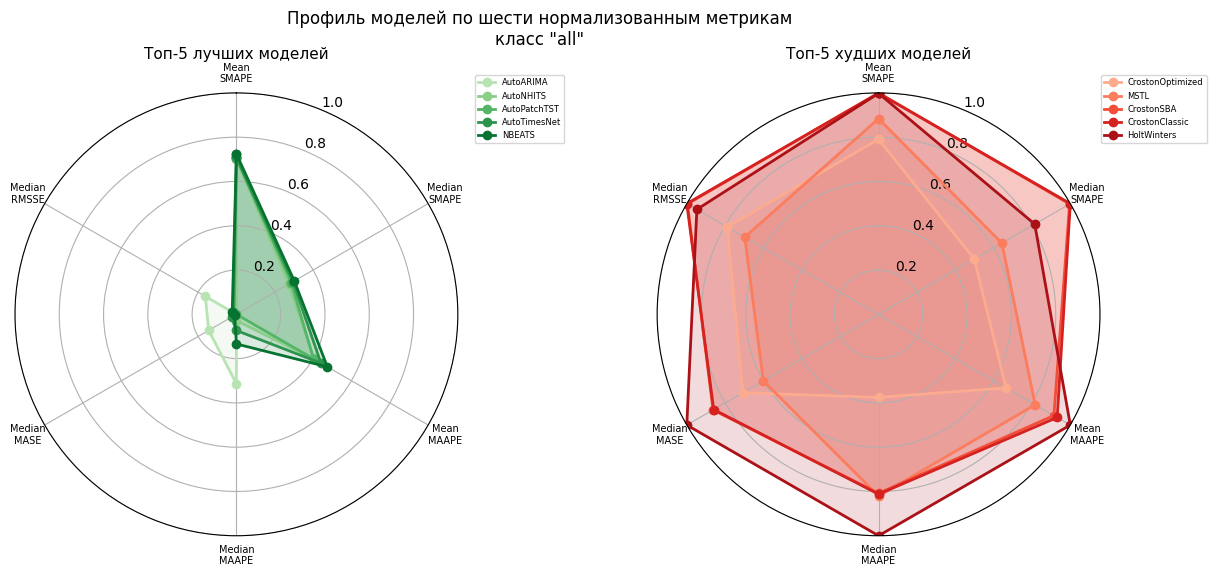

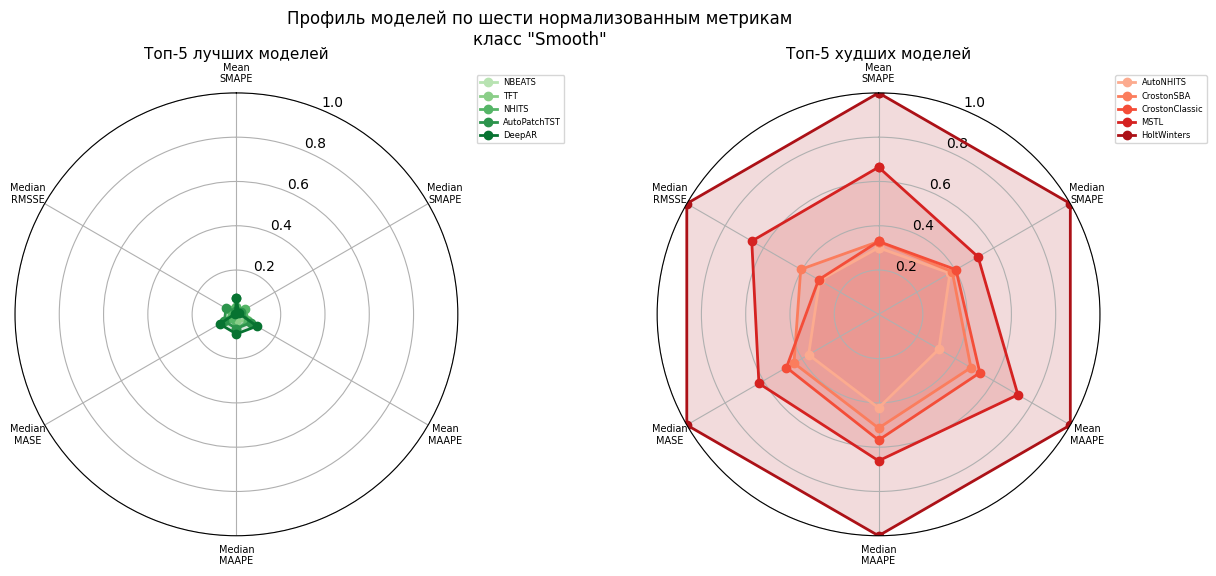

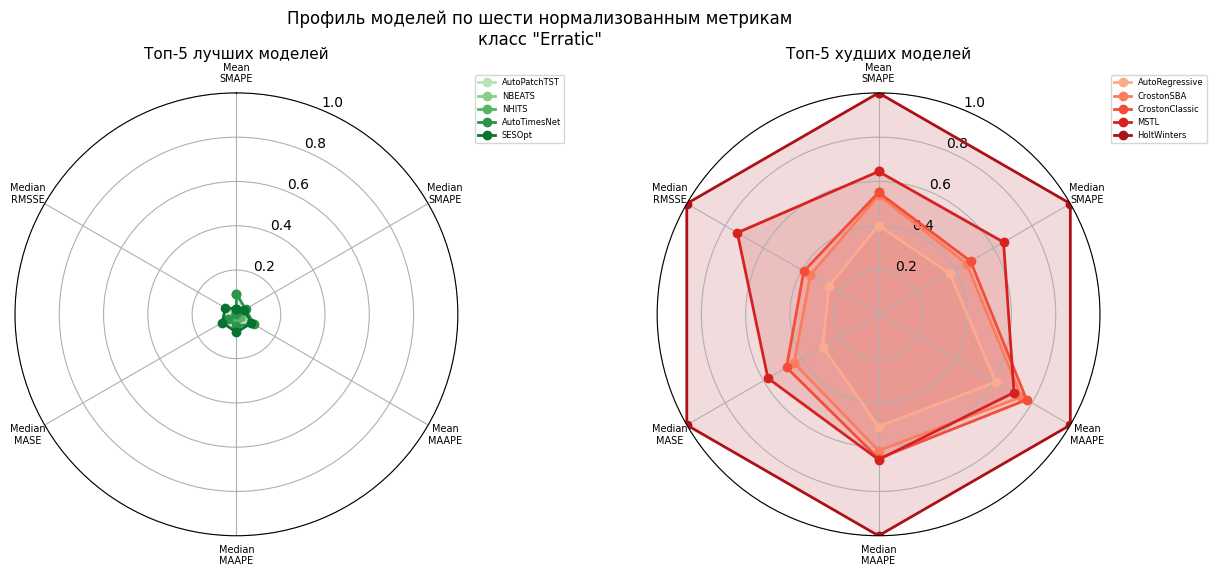

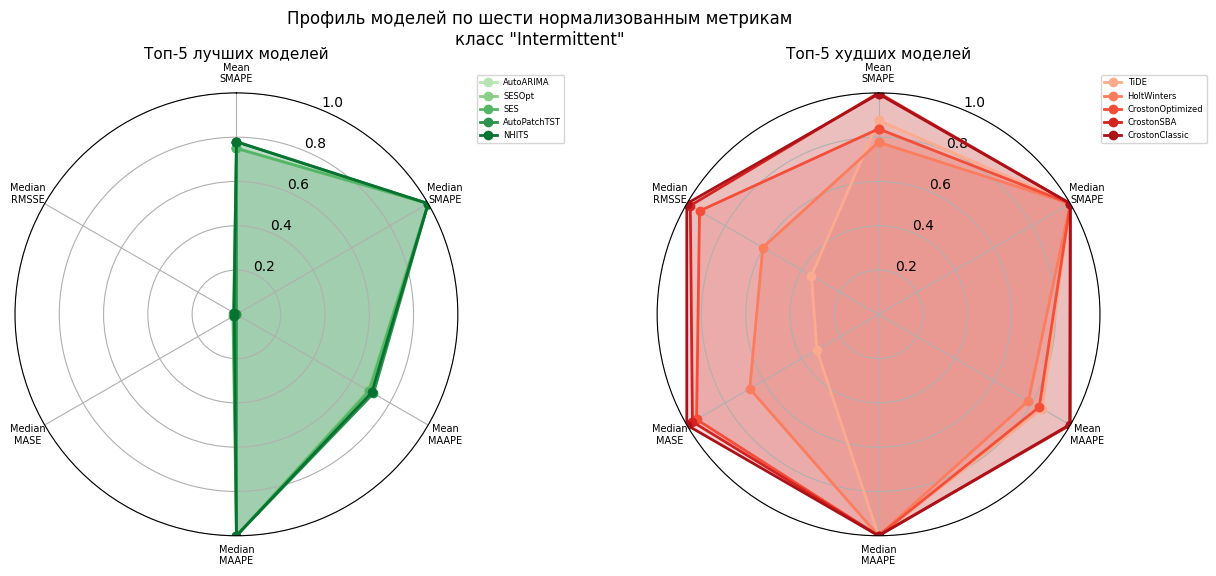

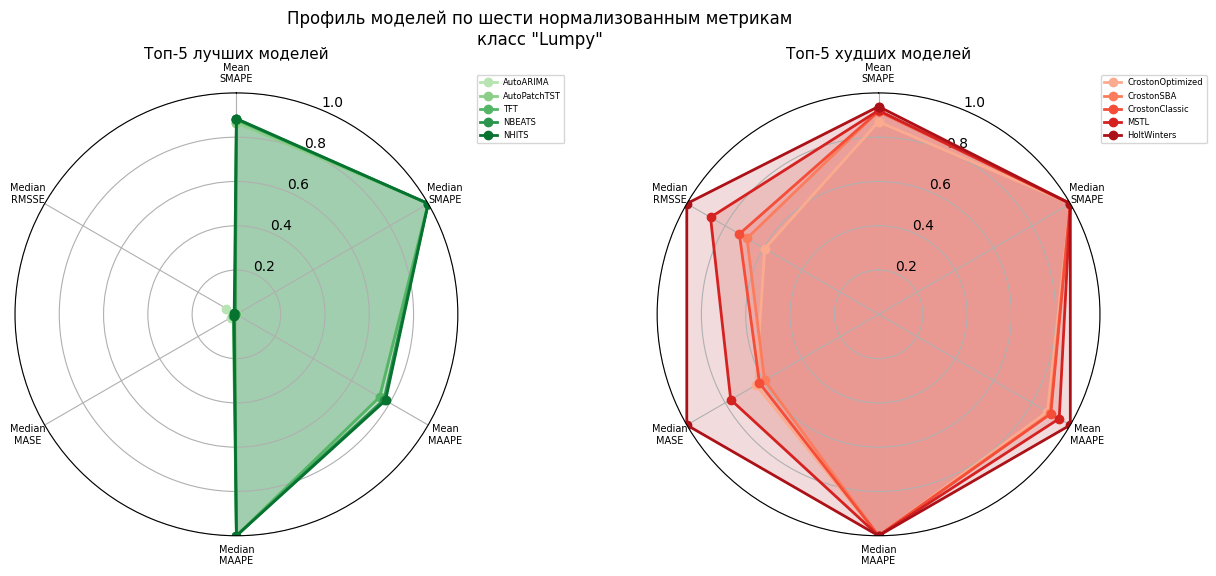

In [15]:
# ------------------------------------------------------------
# 5. Радарные диаграммы для каждого класса
# ------------------------------------------------------------
radar_metrics = ['mean_smape', 'median_smape', 'mean_maape',
                 'median_maape', 'median_mase', 'median_rmsse']
axis_labels = ['Mean\nSMAPE', 'Median\nSMAPE', 'Mean\nMAAPE',
               'Median\nMAAPE', 'Median\nMASE', 'Median\nRMSSE']

def radar_on_axis(ax, data, title, colors):
    N = len(radar_metrics)
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]
    ax.set_theta_offset(pi / 2)
    ax.set_theta_direction(-1)
    for i, (model, row) in enumerate(data.iterrows()):
        values = row[radar_metrics].values.flatten().tolist()
        values += values[:1]
        ax.plot(angles, values, 'o-', linewidth=2, label=model, color=colors[i])
        ax.fill(angles, values, alpha=0.15, color=colors[i])
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(axis_labels, fontsize=7)
    ax.set_ylim(0, 1)
    ax.set_title(title, size=11, pad=12)
    ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1.05), fontsize=6)

for cls in classes:
    df = class_data[cls].copy()
    if df.empty:
        continue
    # нормализация каждой метрики отдельно (0 – лучшая, 1 – худшая)
    scaler = MinMaxScaler()
    df_norm = df.copy()
    df_norm[radar_metrics] = scaler.fit_transform(df[radar_metrics])
    df_norm['avg'] = df_norm[radar_metrics].mean(axis=1)
    df_sorted = df_norm.sort_values('avg')
    best5 = df_sorted.head(5)
    worst5 = df_sorted.tail(5)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7), subplot_kw={'polar': True})
    fig.subplots_adjust(wspace=0.45, top=0.82)
    colors_best = plt.cm.Greens(np.linspace(0.3, 0.85, len(best5)))
    colors_worst = plt.cm.Reds(np.linspace(0.3, 0.85, len(worst5)))
    radar_on_axis(ax1, best5, 'Топ‑5 лучших моделей\n', colors_best)
    radar_on_axis(ax2, worst5, 'Топ‑5 худших моделей\n', colors_worst)
    fig.suptitle(f'Профиль моделей по шести нормализованным метрикам\nкласс "{cls}"',
                 fontsize=12, y=0.9)
    plt.savefig(f'radar_best_worst_{cls}.png', dpi=300, bbox_inches='tight')
    plt.show()


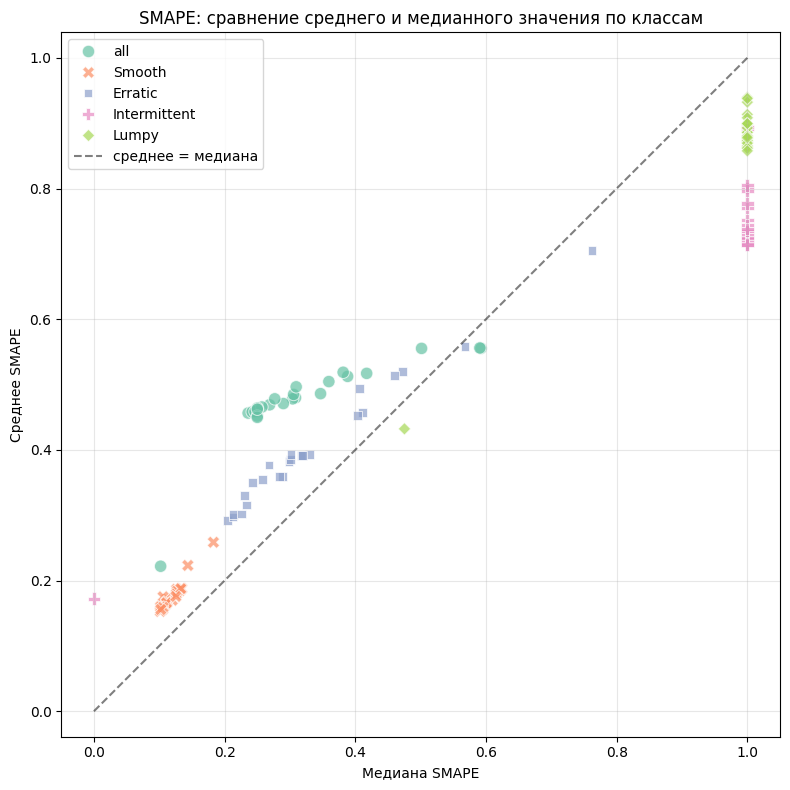

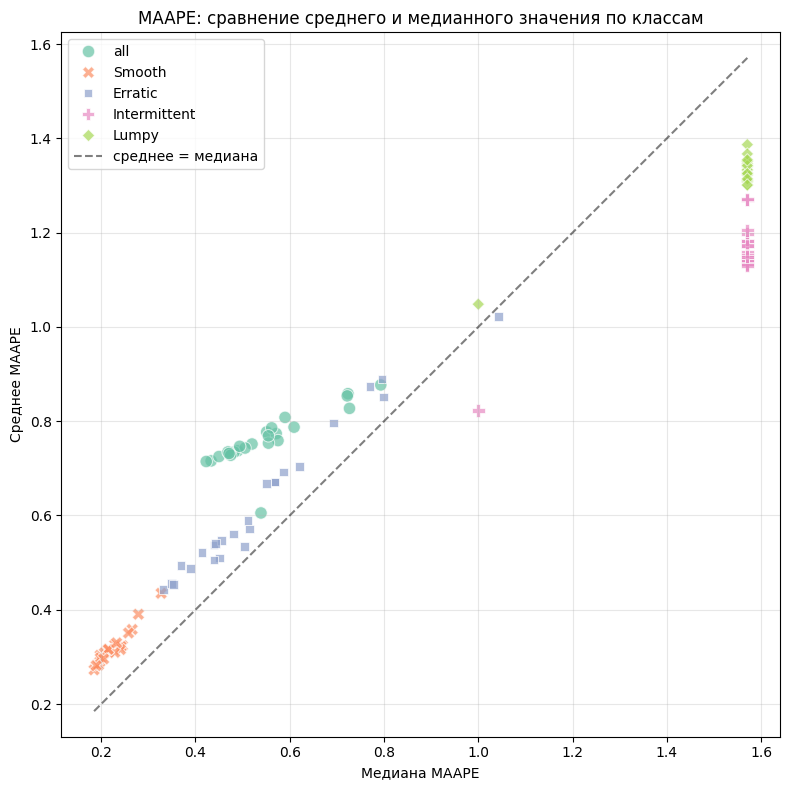

In [19]:
# ------------------------------------------------------------
# Scatter-plot: среднее vs медиана для каждой метрики, цвет = класс
# ------------------------------------------------------------
# Собираем данные из всех классов в один DataFrame
records = []
for cls in classes:
    df = class_data[cls]
    for model in df.index:
        # Для SMAPE
        records.append({
            'model': model,
            'class': cls,
            'metric': 'smape',
            'mean': df.loc[model, 'mean_smape'],
            'median': df.loc[model, 'median_smape']
        })
        # Для MAAPE
        records.append({
            'model': model,
            'class': cls,
            'metric': 'maape',
            'mean': df.loc[model, 'mean_maape'],
            'median': df.loc[model, 'median_maape']
        })


df_merged = pd.DataFrame(records)

# Упорядочим классы
class_order = ['all', 'Smooth', 'Erratic', 'Intermittent', 'Lumpy']
df_merged['class'] = pd.Categorical(df_merged['class'], categories=class_order, ordered=True)

# Построение графиков для каждой метрики
metrics_to_plot = ['smape', 'maape']   # можно добавить 'mase', 'rmsse'

for metric in metrics_to_plot:
    df_sub = df_merged[df_merged['metric'] == metric].copy()
    plt.figure(figsize=(8, 8))
    # Точки с цветом по классу
    sns.scatterplot(data=df_sub, x='median', y='mean', hue='class', style='class',
                    s=80, alpha=0.7, palette='Set2')
    # Линия x=y
    max_val = max(df_sub['median'].max(), df_sub['mean'].max())
    min_val = min(df_sub['median'].min(), df_sub['mean'].min())
    plt.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.5, label='среднее = медиана')
    plt.xlabel(f'Медиана {metric.upper()}')
    plt.ylabel(f'Среднее {metric.upper()}')
    plt.title(f'{metric.upper()}: сравнение среднего и медианного значения по классам')
    plt.legend()
    plt.axis('equal')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'scatter_mean_vs_median_{metric}.png', dpi=300, bbox_inches='tight')
    plt.show()